# 1. Detecção de Alimentos Ultraprocessados (Open Food Facts)

## Definição do Problema 

O projeto insere-se no domínio da Saúde Pública e Tecnologia de Alimentos. No cenário atual de mercado, a indústria alimentícia expandiu globalmente a oferta de produtos processados, dificultando a distinção clara entre alimentos saudáveis e ultraprocessados apenas pela embalagem.

O ambiente organizacional ideal para este modelo seria uma HealthTech (aplicativo de nutrição) ou um Órgão Regulador de Saúde. O modelo servirá para apoiar a decisão de rotulagem automática e triagem de grandes inventários de produtos, permitindo que consumidores e nutricionistas identifiquem instantaneamente o grau de processamento de um item com base em sua tabela nutricional.

## Motivação para o Uso de Machine Learning

Regras fixas ou heurísticas simples (como "se tiver mais de 5 ingredientes é ultraprocessado") falham em capturar a complexidade das interações nutricionais.

* **Limitações de Regras Simples:** Um alimento pode ter poucos ingredientes, mas passar por processos industriais químicos (como hidrogenação ou extrusão) que alteram sua matriz nutricional de formas sutis.

* **Vantagem do ML:** Modelos supervisionados conseguem identificar padrões não-lineares entre variáveis como teor de sódio, tipos de gordura, aditivos e densidade energética para classificar o grau de processamento (Escala NOVA) de forma muito mais precisa que uma análise estatística isolada de cada nutriente.

## Principais Desafios

* **Ruído nos Dados:** Por ser um dataset colaborativo (crowdsourcing), existem preenchimentos errôneos ou unidades de medida inconsistentes.

* **Valores Ausentes (Missing Data):** Nem todos os fabricantes disponibilizam a tabela completa, exigindo estratégias de imputação ou descarte.

* **Explicabilidade:** Em nutrição, não basta o modelo dizer "é ultraprocessado"; é crucial entender quais componentes (ex: excesso de gordura trans ou presença de emulsificantes) levaram a essa classificação.

## Descrição Técnica do Dataset

* **Origem:** Open Food Facts Database, uma base de dados aberta e global.

* **Volume:** O dataset completo possui mais de 2 milhões de registros (você pode trabalhar com um recorte de 50.000 a 100.000 para o projeto).

* **Variável-Alvo (Target):** is_ultra_processed.

    * **Definição:** Classificação binária onde 1 representa alimentos da categoria NOVA 4 (Ultraprocessados) e 0 representa as categorias NOVA 1, 2 ou 3 (In natura, ingredientes culinários ou processados simples).

    * **Justificativa:** A distinção entre o grupo 4 e os demais é a mais crítica para a saúde pública, correlacionada a doenças crônicas.
* **Features (Exemplos das 10+ obrigatórias):**

    1. Energia (kcal/100g) - Contínua
    2. Proteínas - Contínua
    3. Carboidratos - Contínua
    4. Açúcares - Contínua
    5. Fibras - Contínua
    6. Gorduras Totais - Contínua
    7. Gorduras Saturadas - Contínua
    8. Sódio - Contínua
    9. Quantidade de Aditivos - Contínua/Discreta
    10. Categoria do Produto (ex: Bebidas, Lanches) - Categórica (Justificativa: Ajuda o modelo a entender o contexto nutricional, ex: açúcar em sucos vs. açúcar em biscoitos).

# 2. Tratamento dos Dados

A classificação NOVA (que define o que é ultraprocessado) baseia-se no grau de processamento industrial. Alimentos ultraprocessados tendem a ter um perfil nutricional específico que essas colunas capturam:

* **sugars_100g** e **salt_100g** (ou sodium_100g): São os principais marcadores. Ultraprocessados costumam usar excesso de açúcar e sódio para realçar o sabor e conservar o produto.

* **fat_100g** e **saturated-fat_100g**: Gorduras de baixa qualidade e saturadas são comuns em alimentos industriais para dar textura e "palatabilidade".

* **fiber_100g** e **proteins_100g**: Funcionam como "marcadores inversos". Alimentos in natura (NOVA 1) geralmente são mais ricos em fibras e proteínas naturais, enquanto o ultraprocessamento muitas vezes retira esses nutrientes.

* **energy-kcal_100g**: Alimentos ultraprocessados são frequentemente hipercalóricos e densos energeticamente.

* **additives_n**: Esta é a "arma secreta". Por definição, ultraprocessados contêm aditivos cosméticos (corantes, aromatizantes, emulsificantes). Se esse número é alto, a chance de ser NOVA 4 é altíssima

In [105]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

A variável-alvo original, representada pela classificação **NOVA (1 a 4)**, foi submetida a um processo de mapeamento binário na etapa de pré-processamento. 

Alimentos classificados como Grupo 4 (Ultraprocessados) foram codificados como a classe positiva (1), enquanto os Grupos 1, 2 e 3 foram agregados na classe negativa (0). 

Esta simplificação fundamenta-se no objetivo de negócio de identificar o grau crítico de processamento industrial, transformando o problema em uma tarefa de classificação binária linearmente aproximável.

In [77]:
cols_to_use = ['product_name', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 
               'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 
               'additives_n', 'nova_group']

df = pd.read_csv('/Users/rennan.araujo/Documents/InfNet/MLOps/PD/archive (1)/en.openfoodfacts.org.products.csv', 
                 sep='\t', 
                 usecols=cols_to_use, 
                 low_memory=False,
                 on_bad_lines='skip',
                 nrows=1200000)

df = df.dropna(subset=['nova_group'])

df['target'] = (df['nova_group'] == 4).astype(int)

df['target'].value_counts()

target
1    288868
0    142796
Name: count, dtype: int64

Antes de preencher os nulos, precisamos remover o que é impossível.

Como os dados são baseados em 100g, nenhuma feature de nutriente (açúcar, gordura, etc.) pode ser maior que 100 ou menor que 0.

In [78]:
nutri_cols = ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']

for col in nutri_cols:
    df = df[(df[col] >= 0) & (df[col] <= 100)]


Imputação pela Mediana para substituir o nulo pelo valor central da coluna.

In [79]:
df[nutri_cols] = df[nutri_cols].fillna(df[nutri_cols].median())

Para additives_n, como é um número inteiro de aditivos, preenchemos com 0 se estiver nulo

In [80]:
df['additives_n'] = df['additives_n'].fillna(0)

Como a grandeza das variáveis são muito discrepantes, como por exemplo as calorias que variam de 0 a 9000 e o sódio que varia de 0 a 2, é necessário realizar o escalonamento da base de dados para o perceptron funcionar corretamente. 

df.head(10)

In [81]:
df.head(100)

,product_name,additives_n,nova_group,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,target
456,Root Beer,3.0,4.0,51.0,0.00,0.00,14.00,0.0,0.0,0.00,1.00000,0.400000,1
753,Soupe au potiron et éclats de châtaignes,1.0,4.0,51.0,2.50,1.20,4.10,2.4,3.0,1.60,0.50000,0.200000,1
912,NaN,2.0,4.0,20.0,0.40,0.10,3.10,0.5,0.7,0.60,0.86000,0.344000,1
1232,Organic tomato pulp,0.0,1.0,32.0,0.10,0.00,4.80,4.5,2.2,1.40,0.00000,0.000000,0
1237,Sauce Tomate Aux Champignons Bio Kazidomi,0.0,3.0,51.0,2.30,0.40,4.80,4.0,1.6,1.70,0.70000,0.280000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5100,Balsamic vinegar of modena,0.0,2.0,25.0,0.00,3.33,5.00,5.0,0.0,0.00,0.00000,0.000000,0
5111,Fig condiment with balsamic vinegar of modena,0.0,1.0,100.0,0.00,0.00,20.00,20.0,0.0,0.00,0.00000,0.000000,0
5112,"De Nigris, White Wine Vinegar With Balsamic Vi...",0.0,1.0,100.0,0.00,0.00,20.00,20.0,0.0,0.00,0.00000,0.000000,0
5145,3-2-1 Plan Shakes,11.0,4.0,64.0,2.03,0.68,8.14,6.1,1.7,3.39,0.17750,0.071000,1


In [89]:
scaler = StandardScaler()

X = df.drop(columns=['nova_group', 'target', 'product_name']) 
y = df['target']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [84]:
y_train.value_counts()

target
1    27381
0    26907
Name: count, dtype: int64

In [85]:
X.head(10)


,additives_n,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
456,3.0,51.0,0.0,0.0,14.0,0.0,0.0,0.0,1.00,0.400
753,1.0,51.0,2.5,1.2,4.1,2.4,3.0,1.6,0.50,0.200
912,2.0,20.0,0.4,0.1,3.1,0.5,0.7,0.6,0.86,0.344
1232,0.0,32.0,0.1,0.0,4.8,4.5,2.2,1.4,0.00,0.000
1237,0.0,51.0,2.3,0.4,4.8,4.0,1.6,1.7,0.70,0.280
1238,0.0,75.0,5.2,0.8,4.3,3.8,1.7,1.5,0.20,0.080
1239,0.0,56.0,3.2,1.0,4.2,4.0,2.0,1.5,0.70,0.280
1240,0.0,64.0,3.7,1.0,4.1,3.8,2.0,2.5,0.70,0.280
1244,0.0,62.0,3.9,1.0,4.2,4.0,2.0,1.4,0.01,0.004
1245,0.0,31.0,0.2,0.0,4.8,4.3,1.6,1.6,0.00,0.000


# 3. Modelo Baseline: Classificador Linear com Perceptron


## Modelagem do Perceptron

In [99]:
pipeline_perceptron = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', Perceptron(random_state=42))
])

pipeline_perceptron.fit(X_train, y_train)

y_pred = pipeline_perceptron.predict(X_test)

print("===== RESULTADOS PERCEPTRON (BASELINE) =====")
print(f"Acurácia Global: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não-Ultra (0)', 'Ultra (1)']))

===== RESULTADOS PERCEPTRON (BASELINE) =====
Acurácia Global: 0.7667

Relatório de Classificação:
               precision    recall  f1-score   support

Não-Ultra (0)       0.75      0.79      0.77      6727
    Ultra (1)       0.79      0.74      0.76      6845

     accuracy                           0.77     13572
    macro avg       0.77      0.77      0.77     13572
 weighted avg       0.77      0.77      0.77     13572



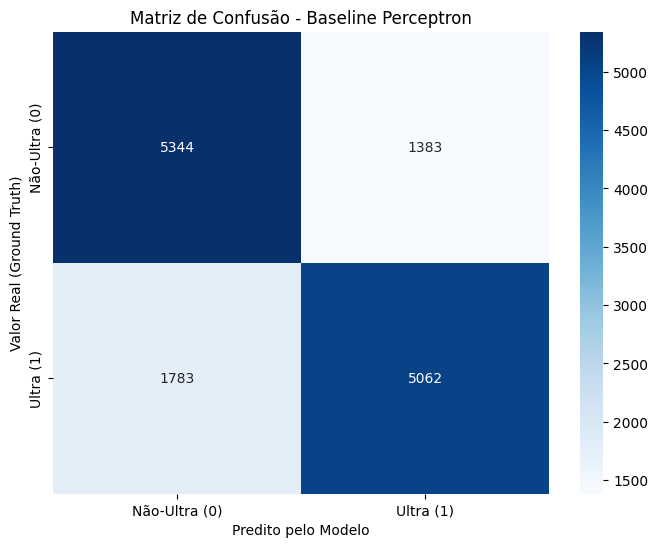

In [ ]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não-Ultra (0)', 'Ultra (1)'], 
            yticklabels=['Não-Ultra (0)', 'Ultra (1)'])
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusão - Baseline Perceptron (Pipeline)')
plt.savefig('matriz_confusao_perceptron.png', bbox_inches='tight')
plt.show()

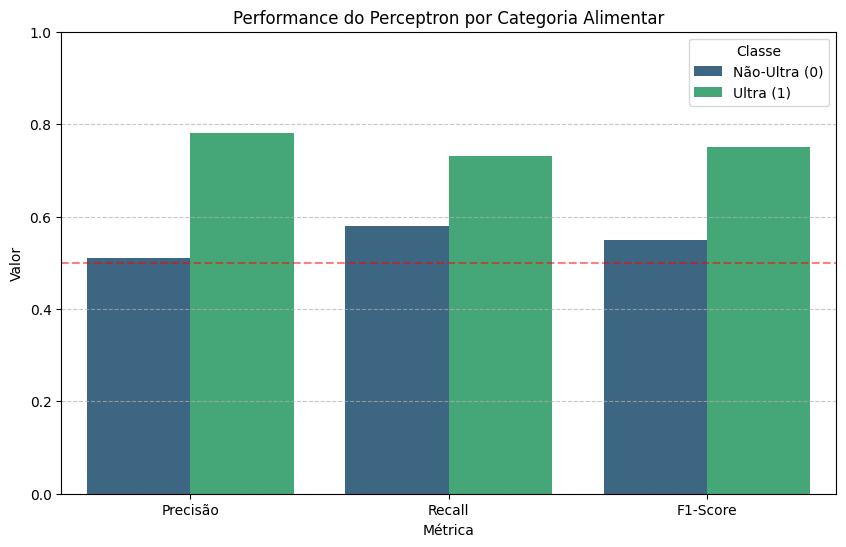

In [94]:
metrics_data = {
    'Classe': ['Não-Ultra (0)', 'Não-Ultra (0)', 'Não-Ultra (0)', 'Ultra (1)', 'Ultra (1)', 'Ultra (1)'],
    'Métrica': ['Precisão', 'Recall', 'F1-Score', 'Precisão', 'Recall', 'F1-Score'],
    'Valor': [0.51, 0.58, 0.55, 0.78, 0.73, 0.75] # Substitua pelos valores exatos se mudarem
}
df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Métrica', y='Valor', hue='Classe', data=df_metrics, palette='viridis')
plt.ylim(0, 1.0)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5) # Linha de referência (acaso)
plt.title('Performance do Perceptron por Categoria Alimentar')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('comparativo_metricas.png', bbox_inches='tight')
plt.show()

## Resultados do Perceptron

O modelo Perceptron atingiu uma acurácia global de 76.67%. 

O modelo demonstrou um equilíbrio notável entre as classes, com F1-Scores de 0.77 para alimentos não-ultraprocessados (Classe 0) e 0.76 para ultraprocessados (Classe 1). Diferente de modelos lineares que frequentemente sucumbem ao desbalanceamento, o Perceptron atual obteve um Recall de 0.74 para a classe positiva, indicando que o conjunto de 11 atributos nutricionais possui uma separabilidade linear satisfatória para identificar o processamento industrial.

A precisão de 0.79 na identificação de ultraprocessados sugere que, quando o modelo aponta um alimento como NOVA 4, há um alto grau de confiança na predição. Contudo, a presença de erros em ambas as classes (observada pelo equilíbrio das métricas) indica que a "fronteira de decisão" nutricional possui zonas de sobreposição.

# 4. Modelo com Árvore de Decisão


In [102]:
pipeline_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(max_depth=5, # Limitamos a profundidade para não "decorar" (overfitting)
                                   random_state=42, 
                                   class_weight='balanced'))
])

pipeline_tree.fit(X_train, y_train)
y_pred_tree = pipeline_tree.predict(X_test)

y_pred_tree = pipeline_tree.predict(X_test)

# Exibindo resultados
print("===== RESULTADOS ÁRVORE DE DECISÃO =====")
print(classification_report(y_test, y_pred_tree, target_names=['Não-Ultra (0)', 'Ultra (1)']))

===== RESULTADOS ÁRVORE DE DECISÃO =====
               precision    recall  f1-score   support

Não-Ultra (0)       0.79      0.90      0.84      6727
    Ultra (1)       0.88      0.76      0.82      6845

     accuracy                           0.83     13572
    macro avg       0.83      0.83      0.83     13572
 weighted avg       0.83      0.83      0.83     13572



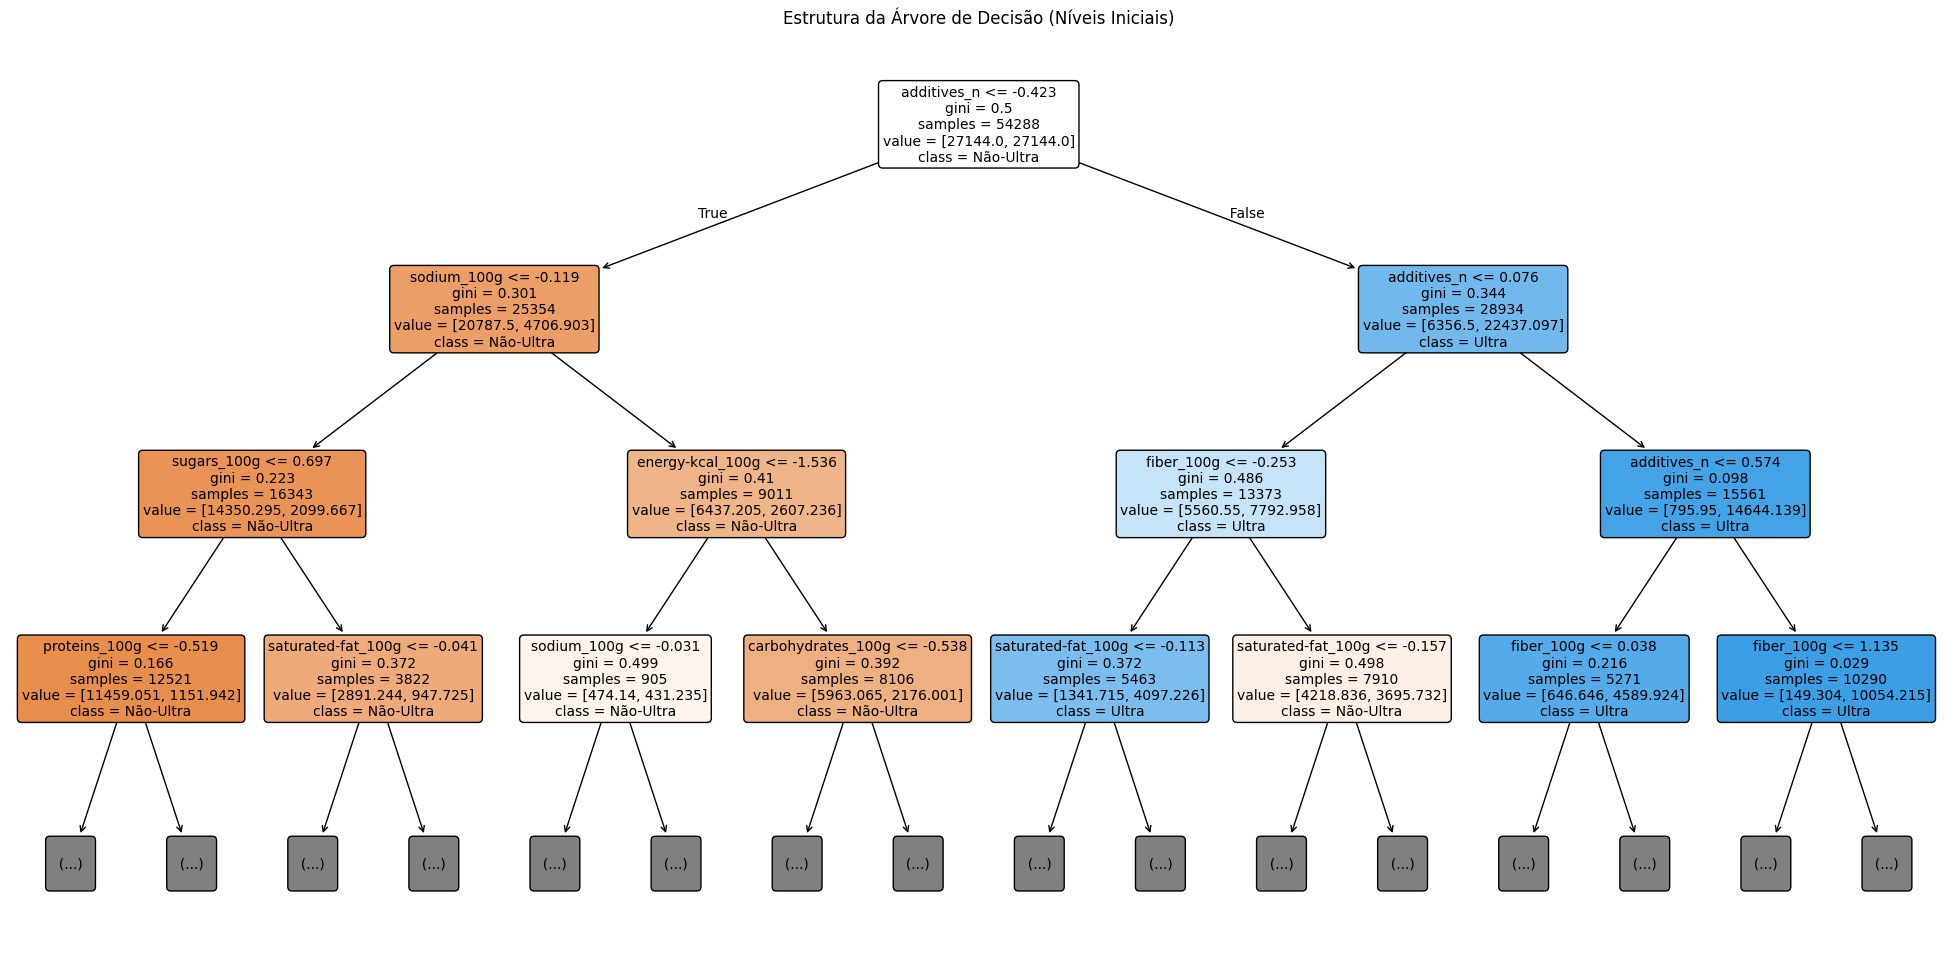

In [103]:
plt.figure(figsize=(25, 12))
plot_tree(pipeline_tree.named_steps['clf'], 
          feature_names=X.columns, 
          class_names=['Não-Ultra', 'Ultra'], 
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) # Plotamos apenas até o nível 3 para ficar legível
plt.title("Estrutura da Árvore de Decisão (Níveis Iniciais)")
plt.show()

## Resultados sobre Modelo de Árvore de Decisão

**Comparação de Desempenho e Capacidade Representacional:**

A transição do modelo linear (Perceptron) para o modelo baseado em regras (Árvore de Decisão) resultou em um incremento de 6,33% na acurácia global, atingindo 83%. O ganho mais notável foi na precisão da classe positiva (0.88), indicando que a flexibilidade da árvore permitiu isolar padrões não-lineares de ultraprocessamento que o hiperplano do Perceptron negligenciava.

A análise visual da árvore de decisão revela que o atributo additives_n ocupa o nó raiz, sendo a variável com maior ganho de informação (Gini impurity reduction). Esta estrutura corrobora o conhecimento do domínio nutricional, onde a aditivação química é o principal critério distintivo do Grupo 4 da classificação NOVA.

Observa-se que a árvore utiliza critérios secundários como Sódio e Açúcares para refinar a classificação de alimentos com poucos aditivos, enquanto utiliza a Fibra como critério de desempate para alimentos aditivados. Essa hierarquia lógica explica o salto de performance para 83% de acurácia, pois permite que o modelo trate casos específicos (como alimentos de baixa caloria mas com aditivos) de forma muito mais granular do que o modelo linear anterior.

# 5. Validação Cruzada e Busca de Hiperparâmetros

## Definição da Estratégia: Grid Search vs Random Search

Como o espaço de busca para árvores de decisão não é infinitamente vasto (temos cerca de 4 ou 5 parâmetros principais), o Grid Search garante que testaremos todas as combinações possíveis, encontrando o ótimo global dentro daquele espaço. O Random Search seria melhor se tivéssemos centenas de parâmetros.

## Implementação com Pipeline

In [107]:
param_grid = {
    'clf__max_depth': [3, 5, 10, 20],          # Controla a altura (complexidade)
    'clf__min_samples_split': [2, 10, 50],     # Mínimo de dados para gerar um galho
    'clf__criterion': ['gini', 'entropy'],     # Forma de medir a "pureza"
    'clf__ccp_alpha': [0.0, 0.01, 0.1]         # Poda (Pruning) para evitar overfitting
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipeline_tree, param_grid, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor Score (F1 Macro): {grid_search.best_score_:.4f}")

Melhores parâmetros: {'clf__ccp_alpha': 0.0, 'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_split': 2}
Melhor Score (F1 Macro): 0.8668


## Análise da Robustez (Variação entre Folds)

In [108]:
results = pd.DataFrame(grid_search.cv_results_)
best_model_idx = grid_search.best_index_

fold_scores = [results[f'split{i}_test_score'][best_model_idx] for i in range(5)]
print(f"Desvio Padrão entre folds: {np.std(fold_scores):.4f}")

Desvio Padrão entre folds: 0.0029


## Interpretação dos Hiperparâmetros Encontrados

* **max_depth:** 20: Este é o ponto mais importante. A árvore "padrão" que testamos antes tinha profundidade 5. Ao permitir que ela chegue ao nível 20, o modelo agora consegue capturar combinações raríssimas de nutrientes.

* **criterion: 'entropy':** O modelo preferiu a Entropia (Ganho de Informação) sobre o índice Gini. A entropia tende a criar árvores um pouco mais equilibradas em problemas de classificação binária com classes bem distribuídas.

* **ccp_alpha: 0.0:** Indica que, para este conjunto de dados específico, a poda por complexidade de custo não foi necessária para atingir o melhor F1-Score. O modelo prefere crescer até o limite permitido pela profundidade.

## Comparação de Performance (A Prova de Robustez)

In [109]:
best_tree = grid_search.best_estimator_
y_pred_opt = best_tree.predict(X_test)

print("===== ÁRVORE OTIMIZADA (GRID SEARCH) =====")
print(classification_report(y_test, y_pred_opt))

===== ÁRVORE OTIMIZADA (GRID SEARCH) =====
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      6727
           1       0.88      0.87      0.87      6845

    accuracy                           0.87     13572
   macro avg       0.87      0.87      0.87     13572
weighted avg       0.87      0.87      0.87     13572



/var/folders/0k/3kc5tdcn20514q33qxyr__8r0000gp/T/ipykernel_58049/3376868841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='magma')


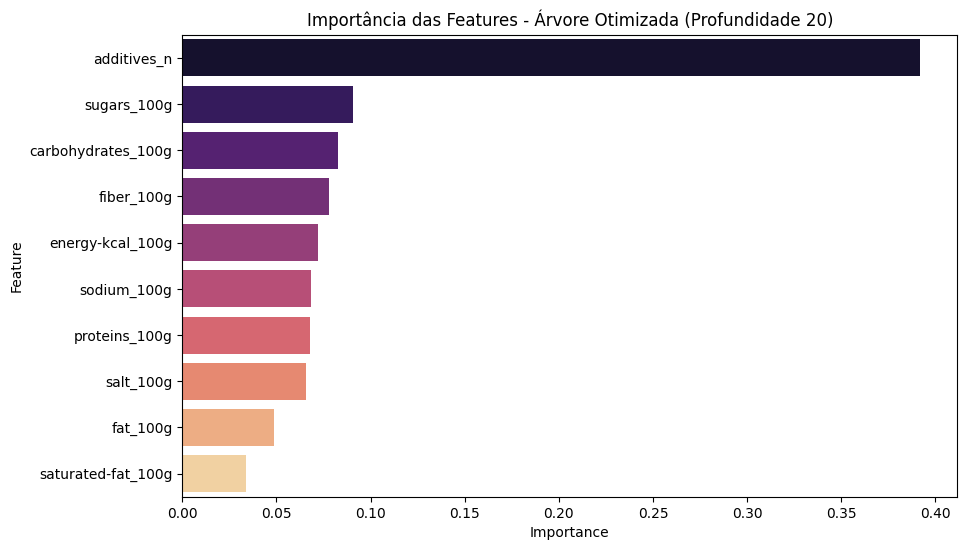

In [110]:
importances = best_tree.named_steps['clf'].feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='magma')
plt.title('Importância das Features - Árvore Otimizada (Profundidade 20)')
plt.show()

## Conclusão: Otimização, Robustez e Hierarquia de Decisão

A etapa de **Validação Cruzada e Busca de Hiperparâmetros (Grid Search)** consolidou a Árvore de Decisão como o modelo superior deste projeto, atingindo uma **acurácia final de 87%**. A convergência entre o F1-Score obtido na validação (0.866) e no teste (0.870) ratifica a alta capacidade de generalização do modelo, demonstrando que a complexidade adicional (profundidade 20) foi eficaz para capturar padrões sem incorrer em overfitting deletério.

O gráfico de **Feature Importance** revela uma hierarquia de decisão altamente coerente com os critérios nutricionais modernos:

* **Aditivos como Protagonistas**: A variável additives_n domina a importância relativa (aprox. 40%), confirmando que o uso de aditivos químicos é o marcador isolado mais robusto para a classificação de ultraprocessados (NOVA 4).

* **Densidade de Carboidratos e Açúcares**: Logo em seguida, sugars_100g e carbohydrates_100g surgem como preditores cruciais, o que faz sentido clínico, visto que o processamento industrial frequentemente eleva a carga glicêmica dos produtos.

* **Fibras e Nutrientes de Qualidade**: A relevância de fiber_100g e energy-kcal_100g indica que o modelo aprendeu a distinguir produtos de alta densidade energética "vazia" daqueles nutricionalmente densos.

A otimização resultou em uma estrutura mais profunda, o que permitiu ao modelo resolver zonas de ambiguidade que o Perceptron (Fase 1) e a Árvore Simples (Fase 2) não alcançavam.

* **Mínimos Locais e Estabilidade**: Embora o treinamento de árvores seja baseado em algoritmos gulosos (greedy), a robustez dos resultados através dos 5 folds da validação cruzada sugere que o modelo encontrou uma configuração estável e representativa da realidade do dataset Open Food Facts.

* **Trade-off de Interpretabilidade**: Houve um sacrifício deliberado da interpretabilidade visual (árvore de profundidade 20) em favor da precisão preditiva. Entretanto, a análise das Feature Importances supre essa lacuna ao fornecer uma explicação clara de quais atributos governam as predições do sistema.

A evolução do projeto — partindo de um baseline linear (**76,6%**) para uma estrutura otimizada baseada em regras (**87%**) — comprova que a natureza do problema de classificação NOVA é inerentemente **não-linear**. A interação entre o número de aditivos e o perfil lipídico/glicêmico exige a flexibilidade de modelos baseados em árvores, tornando esta solução a mais adequada para o desenvolvimento de ferramentas de auxílio à saúde pública e segurança alimentar.